# MC Depth Dose Profile Comparison: AIC-144 vs CCB

This notebook compares Monte Carlo simulated depth dose profiles from AIC-144 and CCB facilities.

In [2]:
# Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add src to path
project_root = Path.cwd().parents[2]
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

## Configuration

In [3]:
# Data directory (same as notebook location)
DATA_DIR = Path.cwd()

# File paths
AIC144_FILE = DATA_DIR / 'mc_aic144_big.csv'
CCB_FILE = DATA_DIR / 'mc_ccb_big.csv'

# Reference dose at X=0 for normalization
REFERENCE_DOSE_GY = 5.0

print(f'AIC-144 file exists: {AIC144_FILE.exists()}')
print(f'CCB file exists: {CCB_FILE.exists()}')

AIC-144 file exists: True
CCB file exists: True


## Load Data

In [4]:
# Load MC depth dose profiles
df_aic144 = pd.read_csv(AIC144_FILE)
df_ccb = pd.read_csv(CCB_FILE)

print('AIC-144 MC data:')
print(df_aic144.head())
print(f'Shape: {df_aic144.shape}')
print(f'Depth range: [{df_aic144["depth"].min():.2f}, {df_aic144["depth"].max():.2f}] mm')
print(f'Dose range: [{df_aic144["dose"].min():.4f}, {df_aic144["dose"].max():.4f}]')
print()
print('CCB MC data:')
print(df_ccb.head())
print(f'Shape: {df_ccb.shape}')
print(f'Depth range: [{df_ccb["depth"].min():.2f}, {df_ccb["depth"].max():.2f}] mm')
print(f'Dose range: [{df_ccb["dose"].min():.4f}, {df_ccb["dose"].max():.4f}]')

AIC-144 MC data:
   depth      dose  dose_err   fluence  fluence_err  kinetic_energy  \
0  0.025  0.239295  0.000787  0.080379     0.000260         57.4614   
1  0.075  0.238369  0.000777  0.080036     0.000256         57.4598   
2  0.125  0.239589  0.000745  0.080410     0.000250         57.4572   
3  0.175  0.238497  0.000847  0.080025     0.000273         57.4476   
4  0.225  0.239227  0.000823  0.080147     0.000269         57.3936   

   kinetic_energy_err  
0            0.002903  
1            0.002942  
2            0.002812  
3            0.002982  
4            0.002938  
Shape: (640, 7)
Depth range: [0.02, 31.98] mm
Dose range: [0.0003, 1.0000]

CCB MC data:
   depth      dose  dose_err   fluence  fluence_err  kinetic_energy  \
0  0.025  0.258738  0.000850  0.080143     0.000258         60.4629   
1  0.075  0.258574  0.000807  0.080145     0.000248         60.4592   
2  0.125  0.258138  0.000756  0.080005     0.000237         60.4580   
3  0.175  0.258569  0.000796  0.080036 

## Normalize Profiles to 5 Gy at X=0

Rescale dose profiles so that the dose at X=0 (or the first data point) equals 5 Gy.

In [5]:
# Find dose at X closest to 0 for normalization
def get_dose_at_x0(df):
    """Get dose value at depth closest to 0."""
    idx_0 = np.abs(df['depth']).argmin()
    return df.iloc[idx_0]['dose']

# Calculate normalization factors
dose_at_0_aic144 = get_dose_at_x0(df_aic144)
dose_at_0_ccb = get_dose_at_x0(df_ccb)

scale_aic144 = REFERENCE_DOSE_GY / dose_at_0_aic144
scale_ccb = REFERENCE_DOSE_GY / dose_at_0_ccb

print(f'AIC-144: dose at X≈0 = {dose_at_0_aic144:.4f}, scale factor = {scale_aic144:.4f}')
print(f'CCB: dose at X≈0 = {dose_at_0_ccb:.4f}, scale factor = {scale_ccb:.4f}')

# Apply normalization
depth_aic144 = df_aic144['depth'].values
dose_aic144 = df_aic144['dose'].values * scale_aic144
dose_err_aic144 = df_aic144['dose_err'].values * scale_aic144

depth_ccb = df_ccb['depth'].values
dose_ccb = df_ccb['dose'].values * scale_ccb
dose_err_ccb = df_ccb['dose_err'].values * scale_ccb

print(f'\nAfter normalization:')
print(f'AIC-144 dose range: [{dose_aic144.min():.2f}, {dose_aic144.max():.2f}] Gy')
print(f'CCB dose range: [{dose_ccb.min():.2f}, {dose_ccb.max():.2f}] Gy')

AIC-144: dose at X≈0 = 0.2393, scale factor = 20.8947
CCB: dose at X≈0 = 0.2587, scale factor = 19.3246

After normalization:
AIC-144 dose range: [0.01, 20.89] Gy
CCB dose range: [0.08, 19.32] Gy


## Depth Dose Profile Comparison

AIC-144 FWHM: 4.87 mm
CCB FWHM: 6.44 mm
AIC-144 90% position: 24.52 mm
CCB 90% position: 26.78 mm


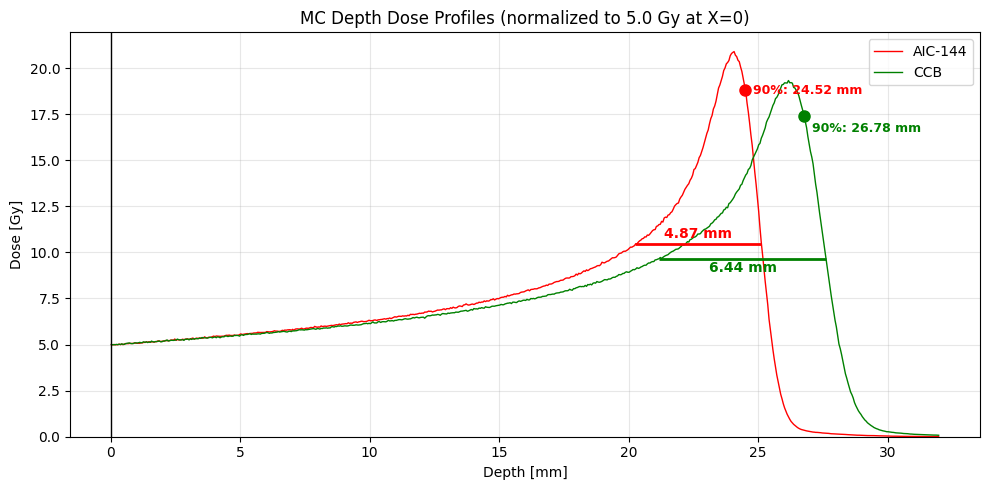

In [6]:
# Helper function to find FWHM boundaries
def find_fwhm_boundaries(profile, x_mm):
    """Find left and right FWHM boundaries."""
    max_val = np.max(profile)
    max_idx = np.argmax(profile)
    half_max = max_val / 2
    
    left_pos = None
    right_pos = None
    
    # Left side
    for i in range(max_idx - 1, -1, -1):
        if profile[i] < half_max <= profile[i + 1]:
            frac = (half_max - profile[i]) / (profile[i + 1] - profile[i])
            left_pos = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    # Right side
    for i in range(max_idx, len(profile) - 1):
        if profile[i] >= half_max > profile[i + 1]:
            frac = (half_max - profile[i]) / (profile[i + 1] - profile[i])
            right_pos = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    return left_pos, right_pos, half_max

# Helper function to find distal position at given percentage of max
def find_distal_percent_position(profile, x_mm, target_percent):
    """Find distal position where dose drops to target_percent of max."""
    max_val = np.max(profile)
    max_idx = np.argmax(profile)
    target_val = max_val * target_percent / 100.0
    
    # Search on distal (right) side after max
    for i in range(max_idx, len(profile) - 1):
        if profile[i] >= target_val > profile[i + 1]:
            # Linear interpolation
            frac = (target_val - profile[i]) / (profile[i + 1] - profile[i])
            x_pos = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            return x_pos, target_val
    return None, None

# Get FWHM boundaries for both profiles
left_aic144, right_aic144, hm_aic144 = find_fwhm_boundaries(dose_aic144, depth_aic144)
left_ccb, right_ccb, hm_ccb = find_fwhm_boundaries(dose_ccb, depth_ccb)

fwhm_aic144 = right_aic144 - left_aic144 if (left_aic144 is not None and right_aic144 is not None) else np.nan
fwhm_ccb = right_ccb - left_ccb if (left_ccb is not None and right_ccb is not None) else np.nan

# Find 90% positions
x_90_aic144, dose_90_aic144 = find_distal_percent_position(dose_aic144, depth_aic144, 90)
x_90_ccb, dose_90_ccb = find_distal_percent_position(dose_ccb, depth_ccb, 90)

print(f'AIC-144 FWHM: {fwhm_aic144:.2f} mm')
print(f'CCB FWHM: {fwhm_ccb:.2f} mm')
print(f'AIC-144 90% position: {x_90_aic144:.2f} mm')
print(f'CCB 90% position: {x_90_ccb:.2f} mm')

# Plot profiles
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(depth_aic144, dose_aic144, color='red', label='AIC-144', linewidth=1)
ax.plot(depth_ccb, dose_ccb, color='green', label='CCB', linewidth=1)

# Add FWHM horizontal segments
# AIC-144 FWHM segment (red)
if left_aic144 is not None and right_aic144 is not None:
    ax.hlines(y=hm_aic144, xmin=left_aic144, xmax=right_aic144, color='red', linewidth=2, linestyle='-')
    ax.text((left_aic144 + right_aic144) / 2, hm_aic144 + 0.15, f'{fwhm_aic144:.2f} mm', 
            ha='center', va='bottom', color='red', fontsize=10, fontweight='bold')

# CCB FWHM segment (green)
if left_ccb is not None and right_ccb is not None:
    ax.hlines(y=hm_ccb, xmin=left_ccb, xmax=right_ccb, color='green', linewidth=2, linestyle='-')
    ax.text((left_ccb + right_ccb) / 2, hm_ccb - 0.15, f'{fwhm_ccb:.2f} mm', 
            ha='center', va='top', color='green', fontsize=10, fontweight='bold')

# Add 90% markers
if x_90_aic144 is not None:
    ax.plot(x_90_aic144, dose_90_aic144, 'o', color='red', markersize=8)
    ax.text(x_90_aic144 + 0.3, dose_90_aic144, f'90%: {x_90_aic144:.2f} mm', 
            ha='left', va='center', color='red', fontsize=9, fontweight='bold')

if x_90_ccb is not None:
    ax.plot(x_90_ccb, dose_90_ccb, 'o', color='green', markersize=8)
    ax.text(x_90_ccb + 0.3, dose_90_ccb - 0.3, f'90%: {x_90_ccb:.2f} mm', 
            ha='left', va='top', color='green', fontsize=9, fontweight='bold')

ax.axvline(x=0, color='black', linestyle='-', linewidth=1)

ax.set_xlabel('Depth [mm]')
ax.set_ylabel('Dose [Gy]')
ax.set_title(f'MC Depth Dose Profiles (normalized to {REFERENCE_DOSE_GY} Gy at X=0)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

## Profile Metrics

Calculate FWHM and distal falloff distances (90%-10% and 80%-20%).

In [7]:
def calculate_profile_metrics(profile, x_mm):
    """Calculate FWHM and distal falloff distances for a profile."""
    max_val = np.max(profile)
    max_idx = np.argmax(profile)
    
    # Normalize profile for percentage calculations
    profile_norm = profile / max_val * 100
    
    # FWHM: find positions where profile crosses 50%
    half_max = 50.0
    
    # Find left and right crossings
    left_idx = None
    right_idx = None
    
    # Left side (before max)
    for i in range(max_idx - 1, -1, -1):
        if profile_norm[i] < half_max <= profile_norm[i + 1]:
            # Linear interpolation
            frac = (half_max - profile_norm[i]) / (profile_norm[i + 1] - profile_norm[i])
            left_idx = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    # Right side (after max) - distal
    for i in range(max_idx, len(profile_norm) - 1):
        if profile_norm[i] >= half_max > profile_norm[i + 1]:
            frac = (half_max - profile_norm[i]) / (profile_norm[i + 1] - profile_norm[i])
            right_idx = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    fwhm = right_idx - left_idx if (left_idx is not None and right_idx is not None) else np.nan
    
    # Distal falloff: find positions for different percentages
    def find_distal_position(target_percent):
        for i in range(max_idx, len(profile_norm) - 1):
            if profile_norm[i] >= target_percent > profile_norm[i + 1]:
                frac = (target_percent - profile_norm[i]) / (profile_norm[i + 1] - profile_norm[i])
                return x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
        return np.nan
    
    pos_90 = find_distal_position(90.0)
    pos_80 = find_distal_position(80.0)
    pos_20 = find_distal_position(20.0)
    pos_10 = find_distal_position(10.0)
    
    dist_90_10 = pos_10 - pos_90 if not (np.isnan(pos_90) or np.isnan(pos_10)) else np.nan
    dist_80_20 = pos_20 - pos_80 if not (np.isnan(pos_80) or np.isnan(pos_20)) else np.nan
    
    return {
        'fwhm': fwhm,
        'pos_90': pos_90,
        'pos_80': pos_80,
        'pos_20': pos_20,
        'pos_10': pos_10,
        'dist_90_10': dist_90_10,
        'dist_80_20': dist_80_20
    }

# Calculate metrics for both profiles
metrics_aic144 = calculate_profile_metrics(dose_aic144, depth_aic144)
metrics_ccb = calculate_profile_metrics(dose_ccb, depth_ccb)

# Display table
print(f'{"Dataset":<12} {"FWHM [mm]":>12} {"90%-10% [mm]":>14} {"80%-20% [mm]":>14}')
print('-' * 54)
print(f'{"AIC-144":<12} {metrics_aic144["fwhm"]:>12.2f} {metrics_aic144["dist_90_10"]:>14.2f} {metrics_aic144["dist_80_20"]:>14.2f}')
print(f'{"CCB":<12} {metrics_ccb["fwhm"]:>12.2f} {metrics_ccb["dist_90_10"]:>14.2f} {metrics_ccb["dist_80_20"]:>14.2f}')

print(f'\n--- Detailed Distal Positions ---')
print(f'{"Dataset":<12} {"90% [mm]":>10} {"80% [mm]":>10} {"20% [mm]":>10} {"10% [mm]":>10}')
print('-' * 54)
print(f'{"AIC-144":<12} {metrics_aic144["pos_90"]:>10.2f} {metrics_aic144["pos_80"]:>10.2f} {metrics_aic144["pos_20"]:>10.2f} {metrics_aic144["pos_10"]:>10.2f}')
print(f'{"CCB":<12} {metrics_ccb["pos_90"]:>10.2f} {metrics_ccb["pos_80"]:>10.2f} {metrics_ccb["pos_20"]:>10.2f} {metrics_ccb["pos_10"]:>10.2f}')

Dataset         FWHM [mm]   90%-10% [mm]   80%-20% [mm]
------------------------------------------------------
AIC-144              4.87           1.40           0.93
CCB                  6.44           1.93           1.28

--- Detailed Distal Positions ---
Dataset        90% [mm]   80% [mm]   20% [mm]   10% [mm]
------------------------------------------------------
AIC-144           24.52      24.70      25.63      25.92
CCB               26.78      27.03      28.31      28.71
